In [695]:
import json, re
import pandas as pd
import numpy as np
from get_electronic import get_electronic_dipole, get_electronic_quadrupole, get_stddev
from os import path
from pathlib import Path
from numpy import sign
import subprocess
from IPython.display import display
import matplotlib.pyplot as plt
import pickle
from math import nan

In [533]:
with open('output.json') as f:
    data = json.load(f)

In [3]:
with open('jacob_ladder.json') as f:
    ladder = json.load(f)

In [4]:
data

{'AlF': [{'name': 'AlF',
   'method': 'BLYP',
   'basis': 'aug-pc-4p',
   'method_type': 'dft',
   'method_level': 2,
   'quadrupoles': [-16.0501, -16.0501, -22.7295],
   'quadrupoles_off_diag': [-0.0, -0.0, -0.0],
   'dipoles': [-0.0, 0.0, -1.4687, 1.4687],
   'quadrupoles_elec': [-11.932880197700001,
    -11.932880197700001,
    -104.86651449752497],
   'dipoles_elec': [-0.0, 0.0, -28.71515488961, 28.71515488961],
   'std_dev': [0.736480580429654, 0.736480580429654, 1.7501494615108055],
   'spin_polarized': 0},
  {'name': 'AlF',
   'method': 'ccsdT',
   'basis': 'aug-cc-pcVQZp',
   'method_type': 'wft',
   'quadrupoles_ccsdt': [-15.765946654685989,
    -15.765946654685989,
    -22.819975731761097],
   'quadrupoles_mp2': [-15.832458569625961,
    -15.832458569625961,
    -22.936119389084194],
   'quadrupoles_ccsd': [-15.69775344747287,
    -15.69775344747287,
    -22.96806393845115],
   'quadrupoles_hf': [-15.7093, -15.7093, -23.7877],
   'dipoles_ccsdt': [0, 0, -1.4655, 1.4655],
   '

# Helper Functions and Variables Initialization

In [5]:
def search(key, value, molecule):
    result = []
    for d in data[molecule]:
        if d[key] == value:
            result.append(d)
    return result

In [6]:
def load():
    global data
    with open('output.json') as f:
        data = json.load(f)

In [7]:
def save(data):
    with open("output.json", 'w') as outfile:
        json.dump(data, outfile)
    result = subprocess.run(['sh', 'commit.sh'], stdout=subprocess.PIPE)
    print(result.stdout)
    print('File saved!')

In [8]:
def save_as(data, name):
    with open(name, 'w') as outfile:
        json.dump(data, outfile)
    print('File saved as {0}!'.format(name))

In [9]:
def retrieve(molecule, method, basis):
    d = data[molecule]
    for m in d:
        if m['method'] == method and m['basis'] == basis:
            return m
    return {}

In [10]:
def get_dft_species():
    result = []
    for v in data.values():
        for d in v:
            if d['method_type'] == 'dft':
                result.append(d['name'])
                break
    return result
def get_wft_species():
    result = []
    for v in data.values():
        for d in v:
            if d['method_type'] == 'wft':
                result.append(d['name'])
                break
    return result

In [11]:
def get_functionals():
    functionals = []
    for v in data.values():
        for n in v:
            if n['method_type'] == 'dft':
                functionals.append(n['method'])
    functionals = np.unique(functionals)
    return functionals

In [524]:
def delete(molecule, method, basis):
    for c, d in enumerate(data[molecule]):
        if d.get('method') == method and d.get('basis') == basis:
            data[molecule].pop(c)
    return

def pop(molecule, method, basis, key):
    for d in data[molecule]:
        if d.get('method') == method and d.get('basis') == basis:
            d.pop(key, None)
    return

def modify(molecule, method, basis, old, new):
    for d in data[molecule]:
        if d.get('method') == method and d.get('basis') == basis:
            d[old] = new
    return

def add(molecule, method, basis, method_type, values):  #adds a new dict to the list of dict for a given molecule
    d = {'name': molecule, 'method': method, 'basis': basis, 'method_type': method_type}
    d.update(values)
    data[molecule].append(d)

In [13]:
from pymatgen.core.periodic_table import Element

In [14]:
def count_e(name):
    if name == 'CH2-t':
        return 8
    l = [a for a in re.split(r'([A-Z][a-z]*)', name) if a]
    c = 0
    e = 0
    prev = ''
    while c < len(l):
        if l[c].isnumeric():
            e -= Element(prev).Z
            e += Element(prev).Z * int(l[c])
        else:
            e += Element(l[c]).Z
            prev = l[c]
        c += 1
    return e

In [849]:
functionals_sorted = sorted(sorted(get_functionals(), key=lambda v: v.upper()), key=lambda x: ladder[x])

In [16]:
def make_dft_table(key, domain=data.keys()):
    """
    Makes a table of molecules in DOMAIN of desired KEY.
    """
    values = []
    index = pd.MultiIndex.from_product([domain], names=['molecule'])
    columns = pd.MultiIndex.from_product([functionals_sorted, ['XX','YY','ZZ']], names=['method', 'component'])
    for d in domain:
        value = data[d]
        temp = [[0, 0, 0] for i in range(len(functionals_sorted))]
        for i in value:
            if i['method_type'] == 'dft':
                method = i['method']
                ind = functionals_sorted.index(method)
                temp[ind] = i[key]
        values.append(np.ravel(temp).tolist())
    df = pd.DataFrame(values, index=index, columns=columns)
    return df
              

In [17]:
wft_method = ['hf', 'MP2', 'CCSD', 'CCSD\(T\)']
wft_basis = ['aug-cc-pcV5Zp', 'aug-cc-pcVQZp', 'aug-cc-pcVTZp', 'CBS']

In [852]:
def make_table_wft_extrap(domain=data.keys()):
    """
    Makes a table of DOMAIN of wft method of desired KEY.
    """
    values = np.array([])
    index = pd.MultiIndex.from_product([domain, ['5Z', 'QZ', 'TZ', 'CBS']], names=['molecule', 'basis'])
    columns = pd.MultiIndex.from_product([wft_method, ['XX','YY','ZZ']], names=['method', 'component'])
    for d in domain:
        m_name = d
        for b in wft_basis:
            temp = [[0, 0, 0] for k in range(len(wft_method))]
            #info = search('basis', b, m_name)
            info = retrieve(m_name, 'ccsdT', b)
            if info == {}:
                info = retrieve(m_name, 'hf', b)
            if info != {}:
                temp[0] = info['std_dev_hf']
                temp[1] = info['std_dev_mp2']
                temp[2] = info['std_dev_ccsd']
                temp[3] = info['std_dev_ccsdt']
            temp = np.ravel(temp)
            values = np.vstack((values, temp)) if values.size else temp
    df = pd.DataFrame(values, index=index, columns=columns)
    return df

In [842]:
#use this cell block for electronic component calculation

input_path = Path.home() / "summer/research/geometries/geometries"
ang_to_bohr = 1.88973
ang2_to_bohr2 = 3.571079
debye_to_e = 0.3934303
ea02_to_debye_ang = 1.345033669
debye_ang_to_ea02 = 0.743477

def get_electronic_dipole(string, dipole):
    info = re.search('molecule\s*\-?\d\s\d\s([\s\S]*?)\$end', string).group(1)
    x = y = z = 0
    for l in info.splitlines():
        line = l.split()
        charge = Element(re.sub('\d+', '', line[0])).Z
        if len(line) == 1:
            line += [0, 0, 0]
        x += charge * float(line[1])
        y += charge * float(line[2])
        z += charge * float(line[3])
    x_elec = dipole[0] * debye_to_e - x * ang_to_bohr
    y_elec = dipole[1] * debye_to_e - y * ang_to_bohr
    z_elec = dipole[2] * debye_to_e - z * ang_to_bohr
    total_elec = np.sqrt(x_elec ** 2 + y_elec ** 2 + z_elec ** 2)
    return [x_elec, y_elec, z_elec, total_elec]

def get_electronic_quadrupole(string, quadrupole):
    info = re.search('molecule\s*\-?\d\s\d\s([\s\S]*?)\$end', string).group(1)
    xx = yy = zz = 0
    for l in info.splitlines():
        line = l.split()
        charge = Element(re.sub('\d+', '', line[0])).Z
        if len(line) == 1:
            line += [0, 0, 0]
        xx += charge * float(line[1]) ** 2
        yy += charge * float(line[2]) ** 2
        zz += charge * float(line[3]) ** 2
    xx_elec = quadrupole[0] * debye_ang_to_ea02 - xx * ang2_to_bohr2
    yy_elec = quadrupole[1] * debye_ang_to_ea02 - yy * ang2_to_bohr2
    zz_elec = quadrupole[2] * debye_ang_to_ea02 - zz * ang2_to_bohr2
    return [xx_elec, yy_elec, zz_elec]

def get_stddev(string, dipole, quadrupole):
    info = re.search('molecule\s*\-?\d\s\d\s([\s\S]*?)\$end', string).group(1)
    tote = abs(int(re.search('molecule\s*(\-?\d\s\d\s)', string).group(1).splitlines()[0].split()[0]))
    for l in info.splitlines():
        line = l.split()
        charge = Element(re.sub('\d+', '', line[0])).Z
        tote += Element(re.sub('\d+', '', line[0])).Z
    xx_std = np.sqrt((quadrupole[0]/-tote) - (dipole[0]/-tote) ** 2)
    yy_std = np.sqrt((quadrupole[1]/-tote) - (dipole[1]/-tote) ** 2)
    zz_std = np.sqrt((quadrupole[2]/-tote) - (dipole[2]/-tote) ** 2)
    return [xx_std, yy_std, zz_std]

def get_electronic_for_wft(molecule, method, basis):
    filename = input_path / "{}.xyz".format(molecule)
    with open(filename, 'r') as file:
        string = file.read()
    d = retrieve(molecule, method, basis)
    if d == {}:
        print('WFT method has not been calculated for {0} of basis {1}!'.format(molecule, basis))
        return
    modify(molecule, method, basis, 'dipoles_elec_hf', get_electronic_dipole(string, d['dipoles_hf']))
    modify(molecule, method, basis, 'dipoles_elec_mp2', get_electronic_dipole(string, d['dipoles_mp2']))
    modify(molecule, method, basis, 'dipoles_elec_ccsd', get_electronic_dipole(string, d['dipoles_ccsd']))
    modify(molecule, method, basis, 'dipoles_elec_ccsdt', get_electronic_dipole(string, d['dipoles_ccsdt']))
    modify(molecule, method, basis, 'quadrupoles_elec_hf', get_electronic_quadrupole(string, d['quadrupoles_hf']))
    modify(molecule, method, basis, 'quadrupoles_elec_mp2', get_electronic_quadrupole(string, d['quadrupoles_mp2']))
    modify(molecule, method, basis, 'quadrupoles_elec_ccsd', get_electronic_quadrupole(string, d['quadrupoles_ccsd']))
    modify(molecule, method, basis, 'quadrupoles_elec_ccsdt', get_electronic_quadrupole(string, d['quadrupoles_ccsdt']))
    modify(molecule, method, basis, 'std_dev_hf', get_stddev(string, d['dipoles_elec_hf'], d['quadrupoles_elec_hf']))
    modify(molecule, method, basis, 'std_dev_mp2', get_stddev(string, d['dipoles_elec_mp2'], d['quadrupoles_elec_mp2']))
    modify(molecule, method, basis, 'std_dev_ccsd', get_stddev(string, d['dipoles_elec_ccsd'], d['quadrupoles_elec_ccsd']))
    modify(molecule, method, basis, 'std_dev_ccsdt', get_stddev(string, d['dipoles_elec_ccsdt'], d['quadrupoles_elec_ccsdt']))
    print('Electronic part successfully calculated for {0} of basis {1}!'.format(molecule, basis))

def get_electronic_for_rmp2(molecule, method, basis):
    filename = input_path / "{}.xyz".format(molecule)
    with open(filename, 'r') as file:
        string = file.read()
    d = retrieve(molecule, method, basis)
    if d == {}:
        print('RMP2 method has not been calculated for {0} of basis {1}!'.format(molecule, basis))
        return
    modify(molecule, method, basis, 'dipoles_elec_mp2', get_electronic_dipole(string, d['dipoles_mp2']))
    modify(molecule, method, basis, 'quadrupoles_elec_mp2', get_electronic_quadrupole(string, d['quadrupoles_mp2']))
    modify(molecule, method, basis, 'std_dev_mp2', get_stddev(string, d['dipoles_elec_mp2'], d['quadrupoles_elec_mp2']))
    print('Electronic part successfully calculated for {0} of basis {1}!'.format(molecule, basis))

def get_electronic_for_hf(molecule, method, basis):
    filename = input_path / "{}.xyz".format(molecule)
    with open(filename, 'r') as file:
        string = file.read()
    d = retrieve(molecule, method, basis)
    if d == {}:
        print('HF method has not been calculated for {0} of basis {1}!'.format(molecule, basis))
        return
    modify(molecule, method, basis, 'dipoles_elec_hf', get_electronic_dipole(string, d['dipoles_hf']))
    modify(molecule, method, basis, 'dipoles_elec_mp2', [0, 0, 0])
    modify(molecule, method, basis, 'dipoles_elec_ccsd', [0, 0, 0])
    modify(molecule, method, basis, 'dipoles_elec_ccsdt', [0, 0, 0])
    modify(molecule, method, basis, 'quadrupoles_elec_hf', get_electronic_quadrupole(string, d['quadrupoles_hf']))
    modify(molecule, method, basis, 'quadrupoles_elec_mp2', [0, 0, 0])
    modify(molecule, method, basis, 'quadrupoles_elec_ccsd', [0, 0, 0])
    modify(molecule, method, basis, 'quadrupoles_elec_ccsdt', [0, 0, 0])
    modify(molecule, method, basis, 'std_dev_hf', get_stddev(string, d['dipoles_elec_hf'], d['quadrupoles_elec_hf']))
    modify(molecule, method, basis, 'std_dev_mp2', [0, 0, 0])
    modify(molecule, method, basis, 'std_dev_ccsd', [0, 0, 0])
    modify(molecule, method, basis, 'std_dev_ccsdt', [0, 0, 0])
    print('Electronic part successfully calculated for {0} of basis {1}!'.format(molecule, basis))
    
def get_electronic_for_dft(molecule, method, basis):
    filename = input_path / "{}.xyz".format(molecule)
    with open(filename, 'r') as file:
        string = file.read()
    d = retrieve(molecule, method, basis)
    if d == {}:
        print('DFT method has not been calculated for {0} of method {1}!'.format(molecule, method))
        return
    modify(molecule, method, basis, 'dipoles_elec', get_electronic_dipole(string, d['dipoles']))
    modify(molecule, method, basis, 'quadrupoles_elec', get_electronic_quadrupole(string, d['quadrupoles']))
    modify(molecule, method, basis, 'std_dev', get_stddev(string, d['dipoles_elec'], d['quadrupoles_elec']))
    print('Electronic part successfully calculated for {0} of method {1}!'.format(molecule, method))

In [20]:
mols = data.keys()
bases = ['aug-cc-pcV5Zp', 'aug-cc-pcVQZp', 'aug-cc-pcVTZp']

In [21]:
def calc_elec_wft(domain):
    """
    Calculates all electronic component for wft methods.
    """
    for m in domain:
        for b in bases:
            get_electronic_for_wft(m, 'ccsdT', b)

In [22]:
def calc_elec_hf(domain):
    """
    Calculates all electronic component for hf methods.
    """
    for m in domain:
        for b in bases:
            get_electronic_for_hf(m, 'hf', b)

In [23]:
def calc_elec_dft(domain):
    """
    Calculates all electronic components for dft methods.
    """
    functionals = get_functionals()
    for m in domain:
        for f in functionals:
            get_electronic_for_dft(m, f, 'aug-pc-4p')

In [24]:
#make extrapolation in this cell 
# TODO: reimplement
def extrapolate(dataframe):
    molecules = dataframe.index[dataframe.index.get_level_values('basis') == 'CBS']
    columns = dataframe.columns
    for m in molecules:
        for c in columns:
            if c[0] == 'hf':
                if dataframe.loc[(m[0], '5Z'), c] != 0:
                    dataframe.loc[m, c] = dataframe.loc[(m[0], '5Z'), c]
                else:
                    dataframe.loc[m, c] = dataframe.loc[(m[0], 'QZ'), c]
            if dataframe.loc[(m[0], '5Z'), c] != 0:
                dataframe.loc[m, c] = ((dataframe.loc[(m[0], '5Z'), c] - dataframe.loc[(m[0], '5Z'), ('hf', c[1])]) * 125
                                       - (dataframe.loc[(m[0], 'QZ'), c] - dataframe.loc[(m[0], 'QZ'), ('hf', c[1])]) * 64) \
                                       / (125 - 64) + dataframe.loc[(m[0], 'CBS'), ('hf', c[1])]
            else:
                dataframe.loc[m, c] = ((dataframe.loc[(m[0], 'QZ'), c] - dataframe.loc[(m[0], 'QZ'), ('hf', c[1])]) * 64
                                       - (dataframe.loc[(m[0], 'TZ'), c] - dataframe.loc[(m[0], 'TZ'), ('hf', c[1])]) * 27) \
                                       / (64 - 27) + dataframe.loc[(m[0], 'CBS'), ('hf', c[1])]
    display(dataframe)

# Workspace

In [80]:
def compile_wft(domain=get_wft_species()):
    """
    Compiles all wft values.
    """
    calc_elec_wft(domain)
    calc_elec_hf(domain)
    std_dev_wft = make_table_wft_extrap(domain)
    extrapolate(std_dev_wft)
    return std_dev_wft

In [827]:
def make_wft_spreadsheet(domain=get_wft_species()):
    """
    Compiles all wft values to a spreadsheet.
    """
    std_dev_wft = compile_wft(domain)
    std_dev_wft.to_csv('wft_table_temp.csv')
    return std_dev_wft

In [82]:
def compile_dft(domain=get_dft_species()):
    std_dev_dft = make_dft_table('std_dev', domain) # change to dft species once all wft calcs are done.
    return std_dev_dft

In [826]:
def make_dft_spreadsheet(domain=get_wft_species()):
    """
    Compiles all dft values to a spreadsheet.
    """
    std_dev_dft = compile_dft(domain)
    std_dev_dft.to_csv('dft_table_temp.csv')
    return std_dev_dft

In [945]:
domain = get_dft_species()
domain.remove('C2H-')
#domain.remove('CH3-')
#domain.remove('CN-')
#domain.remove('OH-')
#domain.remove('SH-')
#domain.remove('NH2-')
#domain.remove('BH4-')

In [954]:
std_dev_wft = make_wft_spreadsheet(domain)
std_dev_dft = make_dft_spreadsheet(domain)

WFT method has not been calculated for AlF of basis aug-cc-pcV5Zp!
Electronic part successfully calculated for AlF of basis aug-cc-pcVQZp!
Electronic part successfully calculated for AlF of basis aug-cc-pcVTZp!
Electronic part successfully calculated for Ar of basis aug-cc-pcV5Zp!
Electronic part successfully calculated for Ar of basis aug-cc-pcVQZp!
Electronic part successfully calculated for Ar of basis aug-cc-pcVTZp!
Electronic part successfully calculated for BeH of basis aug-cc-pcV5Zp!
Electronic part successfully calculated for BeH of basis aug-cc-pcVQZp!
Electronic part successfully calculated for BeH of basis aug-cc-pcVTZp!
Electronic part successfully calculated for BeH2 of basis aug-cc-pcV5Zp!
Electronic part successfully calculated for BeH2 of basis aug-cc-pcVQZp!
Electronic part successfully calculated for BeH2 of basis aug-cc-pcVTZp!
Electronic part successfully calculated for BF of basis aug-cc-pcV5Zp!
Electronic part successfully calculated for BF of basis aug-cc-pcVQZp!

HF method has not been calculated for HF of basis aug-cc-pcV5Zp!
HF method has not been calculated for HF of basis aug-cc-pcVQZp!
HF method has not been calculated for HF of basis aug-cc-pcVTZp!
Electronic part successfully calculated for HNC of basis aug-cc-pcV5Zp!
HF method has not been calculated for HNC of basis aug-cc-pcVQZp!
HF method has not been calculated for HNC of basis aug-cc-pcVTZp!
Electronic part successfully calculated for LiBH4 of basis aug-cc-pcV5Zp!
HF method has not been calculated for LiBH4 of basis aug-cc-pcVQZp!
HF method has not been calculated for LiBH4 of basis aug-cc-pcVTZp!
HF method has not been calculated for Mg of basis aug-cc-pcV5Zp!
HF method has not been calculated for Mg of basis aug-cc-pcVQZp!
HF method has not been calculated for Mg of basis aug-cc-pcVTZp!
HF method has not been calculated for Mg2 of basis aug-cc-pcV5Zp!
HF method has not been calculated for Mg2 of basis aug-cc-pcVQZp!
HF method has not been calculated for Mg2 of basis aug-cc-pcVTZp

method                hf                           MP2                      \
component             XX        YY        ZZ        XX        YY        ZZ   
molecule basis                                                               
AlF      5Z     0.728543  0.728543  1.762194  0.000000  0.000000  0.000000   
         QZ     0.728620  0.728620  1.762230  0.731470  0.731470  1.752314   
         TZ     0.729178  0.729178  1.762396  0.733437  0.733437  1.753416   
         CBS    0.728543  0.728543  1.762194  0.730366  0.730366  1.751594   
Ar       5Z     0.694399  0.694399  0.694399  0.693865  0.693865  0.693865   
...                  ...       ...       ...       ...       ...       ...   
OH-      CBS    0.866045  0.866045  0.932461  0.921298  0.921298  0.963598   
SH-      5Z     0.944153  0.944153  1.024041  0.950195  0.950195  1.029848   
         QZ     0.944022  0.944022  1.023879  0.951015  0.951015  1.030364   
         TZ     0.943777  0.943777  1.023690  0.952499  0.952499  1.031879   
         CBS    0.944153  0.944153  1.024041  0.949198  0.949198  1.029136   

method              CCSD                     CCSD\(T\)                      
component             XX        YY        ZZ        XX        YY        ZZ  
molecule basis                                                              
AlF      5Z     0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  
         QZ     0.728352  0.728352  1.752450  0.729932  0.729932  1.751065  
         TZ     0.730298  0.730298  1.753317  0.731928  0.731928  1.752099  
         CBS    0.727263  0.727263  1.751902  0.728807  0.728807  1.750396  
Ar       5Z     0.692929  0.692929  0.692929  0.693342  0.693342  0.693342  
...                  ...       ...       ...       ...       ...       ...  
OH-      CBS    0.895030  0.895030  0.949575  0.908920  0.908920  0.958136  
SH-      5Z     0.941976  0.941976  1.025693  0.945586  0.945586  1.028354  
         QZ     0.942832  0.942832  1.026287  0.946500  0.946500  1.028957  
         TZ     0.945541  0.945541  1.028666  0.949230  0.949230  1.031393  
         CBS    0.940940  0.940940  1.024899  0.944488  0.944488  1.027551  

[368 rows x 12 columns]

In [957]:
std_dev_wft.loc['CH3-']['MN15-L']

component,XX,YY,ZZ
molecule,,,
HBS,0.824368,0.824368,1.741455


In [855]:
save(data)

b"\x1bSaving updates to GitHub...\x1b\nOn branch master\nYour branch is up to date with 'origin/master'.\n\nChanges not staged for commit:\n\tmodified:   ../geometries/cbs_limit/BN_ccsdT_aug-cc-pcV5Z.inp\n\tdeleted:    ../geometries/cbs_limit/BN_ccsdT_aug-cc-pcVDZ.inp\n\tmodified:   ../geometries/cbs_limit/BN_ccsdT_aug-cc-pcVQZ.inp\n\tmodified:   ../geometries/cbs_limit/BN_ccsdT_aug-cc-pcVTZ.inp\n\tmodified:   ../geometries/cbs_limit/CS_ccsdT_aug-cc-pcV5Z.inp\n\tdeleted:    ../geometries/cbs_limit/CS_ccsdT_aug-cc-pcVDZ.inp\n\tmodified:   ../geometries/cbs_limit/CS_ccsdT_aug-cc-pcVQZ.inp\n\tmodified:   ../geometries/cbs_limit/CS_ccsdT_aug-cc-pcVTZ.inp\n\tmodified:   ../geometries/cbs_limit/LiCl_ccsdT_aug-cc-pcV5Z.inp\n\tdeleted:    ../geometries/cbs_limit/LiCl_ccsdT_aug-cc-pcVDZ.inp\n\tmodified:   ../geometries/cbs_limit/LiCl_ccsdT_aug-cc-pcVQZ.inp\n\tmodified:   ../geometries/cbs_limit/LiCl_ccsdT_aug-cc-pcVTZ.inp\n\tdeleted:    ../geometries/cbs_limit/LiCl_ccsdT_dz.inp\n\tmodified:   .

In [412]:
non_polar

['Ar',
 'BeH2',
 'BH3',
 'C2H2',
 'CH3',
 'CH4',
 'CO2',
 'F2',
 'H',
 'H2',
 'He',
 'Mg',
 'Mg2',
 'N',
 'N2',
 'Na',
 'Na2',
 'Ne',
 'O2',
 'P',
 'C2H4',
 'Cl2',
 'Li',
 'P2',
 'S2',
 'SiH4']

In [943]:
missing_dipoles = []
for m in get_wft_species():
    for b in wft_basis[0:-1]:
        temp = retrieve(m, 'ccsdT', b)
        temp1 = retrieve(m, 'hf', b)
        if temp != {}:
            temp = retrieve(m, 'ccsdT', b)['dipoles_mp2']
        if (temp == [] or temp == {}) and temp1 == {}:
            missing_dipoles.append((m, b))

In [944]:
missing_dipoles

[('Mg', 'aug-cc-pcV5Zp'),
 ('Mg2', 'aug-cc-pcV5Zp'),
 ('Na', 'aug-cc-pcV5Zp'),
 ('Na2', 'aug-cc-pcV5Zp'),
 ('NaLi', 'aug-cc-pcV5Zp'),
 ('C2H-', 'aug-cc-pcV5Zp')]

In [421]:
current_species = ['AlF','Ar','BeH','BeH2','BF','BH2','BH2F','BH3','BO','BS','C2H','C2H2','CH2BH','CH2-t','CH3','CH4','ClF','CN','CO','CO2','F2','FCN','H','H2','H2CN','H2O','HBO','HCCF','HCN','He','HF','HNC','LiBH4','Mg','Mg2','N','N2','Na','Na2','NaCl','Ne','NH2','NH3','NH3O','O2','O3','P','HCl','NH','PH','LiH']
dft_old = make_dft_table('std_dev', current_species)
wft_old = make_table_wft_extrap(current_species)
extrapolate(wft_old)

method                hf                           MP2                      \
component             XX        YY        ZZ        XX        YY        ZZ   
molecule basis                                                               
AlF      5Z     0.728543  0.728543  1.762194  0.000000  0.000000  0.000000   
         QZ     0.728620  0.728620  1.762230  0.731470  0.731470  1.752314   
         TZ     0.729178  0.729178  1.762396  0.733437  0.733437  1.753416   
         CBS    0.728543  0.728543  1.762194  0.730366  0.730366  1.751594   
Ar       5Z     0.694399  0.694399  0.694399  0.693865  0.693865  0.693865   
...                  ...       ...       ...       ...       ...       ...   
PH       CBS    0.818046  0.818046  1.038866  0.816495  0.816495  1.032381   
LiH      5Z     0.987089  0.987089  1.651807  0.987782  0.987782  0.769935   
         QZ     0.987146  0.987146  1.651777  0.988522  0.988522  1.646651   
         TZ     0.988021  0.988021  1.651583  0.991225  0.991225  1.546393   
         CBS    0.987089  0.987089  1.651807  0.987065  0.987065 -0.149931   

method              CCSD                     CCSD\(T\)                      
component             XX        YY        ZZ        XX        YY        ZZ  
molecule basis                                                              
AlF      5Z     0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  
         QZ     0.728352  0.728352  1.752450  0.729932  0.729932  1.751065  
         TZ     0.730298  0.730298  1.753317  0.731928  0.731928  1.752099  
         CBS    0.727263  0.727263  1.751902  0.728807  0.728807  1.750396  
Ar       5Z     0.692929  0.692929  0.692929  0.693342  0.693342  0.693342  
...                  ...       ...       ...       ...       ...       ...  
PH       CBS    0.814809  0.814809  1.032174  0.815134  0.815134  1.032071  
LiH      5Z     0.995761  0.995761  0.772904  0.995880  0.995880  0.774470  
         QZ     0.996375  0.996375  1.645965  0.996507  0.996507  1.645823  
         TZ     0.999088  0.999088  1.536849  0.999238  0.999238  1.540299  
         CBS    0.995175  0.995175 -0.143126  0.995281  0.995281 -0.139768  

[204 rows x 12 columns]

In [382]:
dft_old.to_csv('dft_old.csv')

In [42]:
uneq = []
for d in get_wft_species():
    temp = retrieve(d, 'ccsdT', 'aug-cc-pcVTZp')
    if temp != {}:
        if temp['quadrupoles_hf'][0] != temp['quadrupoles_hf'][1]:
            uneq.append(d)

In [116]:
save(data)

b'\x1bSaving updates to GitHub...\x1b\n[master 9a53102] save Sun, Sep 13, 2020  4:09:25 PM\n 12 files changed, 5888 insertions(+), 2085 deletions(-)\n create mode 100644 output/dft/missing/20-09-13/BH2F_wB97M-V_aug-pc-4p.out\n create mode 100644 output/dft/missing/20-09-13/BH2F_wB97X-V_aug-pc-4p.out\n create mode 100644 output/dft/missing/20-09-13/BH3_wB97X-V_aug-pc-4p.out\n create mode 100644 output/dft/missing/20-09-13/CH2-t_wB97X-V_aug-pc-4p.out\n create mode 100644 output/dft/missing/20-09-13/CH3_wB97M-V_aug-pc-4p.out\n create mode 100644 output/dft/missing/20-09-13/Li_wB97M-V_aug-pc-4p.out\n create mode 100644 output/dft/missing/20-09-13/SH2_wB97X-V_aug-pc-4p.out\n rewrite output/output.json (72%)\n'
File saved!


# CSV to Pandas workspace

In [298]:
def get_error_table(error_type):
    err = pd.read_excel('total_table_abs.xlsx', error_type, header=[0, 1], index_col=0).loc['AlF':'SO-trip']
    err.drop(['CCSD\(T\)', 'Error:'], axis=1, inplace=True)
    return err

## Challenging species

In [678]:
def make_c_s_dist(dataframe):
    c_s_dist = []
    for i in dataframe.columns.get_level_values(0).unique():
        temp = []
        for j in dataframe.index:
            temp.append(np.sqrt(np.mean(dataframe[i].loc[j] ** 2)))
        c_s_dist.append(temp)
    return np.array(c_s_dist).T

In [679]:
abs_err = get_error_table('absolute_error')

c:\users\eligh\appdata\local\programs\python\python37\lib\site-packages\pandas\core\generic.py:3936: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  obj = obj._drop_axis(labels, axis, level=level, errors=errors)


In [680]:
c_s_dist_table = pd.DataFrame(make_c_s_dist(abs_err), 
                              columns=abs_err.columns.get_level_values(0).unique(), index=abs_err.index) * 100
c_s_dist_table

method,HF,MP2,CCSD,Slater,SPW92,B97-D3,BLYP,BPBE,mPW91,N12,...,M06,M08-HX,MN15,SCAN0,TPSSh,CAM-B3LYP,wB97X-D,wB97X-V,wB97M-V,wM05-D
molecule,,,,,,,,,,,,,,,,,,,,,
AlF,0.681487,0.144898,0.153126,1.599824,0.586252,0.434093,0.626744,0.346164,0.447430,0.224211,...,0.432490,0.282071,0.702265,0.117981,0.269683,0.237877,0.140366,0.323574,0.396421,0.089905
Ar,0.154553,0.054824,0.038370,1.167285,0.505206,0.056636,0.622882,0.216684,0.316453,0.161421,...,0.000919,0.281431,0.118411,0.027144,0.148902,0.435335,0.046807,0.263320,0.471168,0.190827
BeH,1.252133,0.545435,0.102886,3.979257,2.237910,1.509002,1.334177,0.907611,1.134291,2.122974,...,0.851790,1.196656,3.201529,0.504243,0.665868,0.726335,0.884546,0.741636,2.586088,1.134482
BeH2,0.773929,0.228801,0.068455,3.753023,2.059127,0.861587,1.183342,0.747957,0.953876,0.949715,...,0.368665,1.002456,1.436192,0.308105,0.164347,0.928566,0.667864,0.709788,1.370009,0.974436
BF,0.851567,0.399087,0.166877,2.188371,1.074508,0.598619,0.999080,0.558941,0.699847,0.444770,...,0.201115,0.474196,0.541620,0.323526,0.389856,0.672237,0.421697,0.597718,0.780494,0.434418
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SiH3Cl,0.353535,0.076963,0.017825,0.829238,0.167838,0.064555,0.387699,0.018212,0.075345,0.253927,...,0.089266,0.354018,0.174217,0.012459,0.015559,0.269552,0.025242,0.161860,0.395781,0.152967
SiH3F,0.188282,0.100368,0.036165,0.929815,0.260064,0.197037,0.495747,0.129177,0.202656,0.127959,...,0.100753,0.377640,0.338937,0.022393,0.071833,0.313574,0.022165,1.644519,0.445390,0.190276
SiH4,0.527737,0.083634,0.012496,1.182205,0.290256,0.190163,0.515279,0.000567,0.123813,0.118576,...,0.115076,0.538361,0.504836,0.033876,0.039194,0.413735,0.025411,0.268776,0.593666,0.267123


In [682]:
c_s_dist_table.to_clipboard()

## Top Error Contributors

In [383]:
def get_top_err(n, dataframe):
    return [tuple(dataframe[c].astype('float64').nlargest(n).index) for c in dataframe.columns]   

In [384]:
get_top_err(3, abs_err)

[('Mg', 'Mg2', 'Na'),
 ('Mg', 'Mg2', 'Na'),
 ('NaLi', 'CS', 'Na2'),
 ('NaLi', 'C2H', 'HCHS'),
 ('NaLi', 'C2H', 'HCP'),
 ('CS', 'OF2', 'BeH'),
 ('Na2', 'NaLi', 'Mg'),
 ('Na2', 'NaLi', 'Mg'),
 ('CS', 'SiO', 'CO'),
 ('LiH', 'H', 'BeH'),
 ('LiH', 'H', 'BeH'),
 ('H', 'NaLi', 'CS'),
 ('H', 'LiH', 'BeH'),
 ('H', 'LiH', 'BeH'),
 ('H', 'CS', 'H2'),
 ('Na', 'H', 'LiH'),
 ('Na', 'H', 'LiH'),
 ('CS', 'Na', 'H'),
 ('H', 'LiH', 'He'),
 ('H', 'LiH', 'He'),
 ('CS', 'H', 'NaLi'),
 ('H', 'LiH', 'He'),
 ('H', 'LiH', 'He'),
 ('CS', 'H', 'NaLi'),
 ('H', 'LiH', 'He'),
 ('H', 'LiH', 'He'),
 ('CS', 'H', 'NaLi'),
 ('H', 'LiH', 'Na'),
 ('H', 'LiH', 'Na'),
 ('H', 'CS', 'Na'),
 ('H', 'LiH', 'BeH'),
 ('H', 'LiH', 'BeH'),
 ('CS', 'H', 'NaLi'),
 ('LiH', 'H2', 'Li'),
 ('LiH', 'H2', 'Li'),
 ('NaLi', 'H2', 'CS'),
 ('Li', 'H', 'BeH'),
 ('Li', 'H', 'BeH'),
 ('Li', 'CS', 'H'),
 ('Li', 'Na2', 'NaLi'),
 ('Li', 'Na2', 'NaLi'),
 ('CS', 'Li', 'NaH'),
 ('H', 'He', 'LiH'),
 ('H', 'He', 'LiH'),
 ('CS', 'H', 'NaLi'),
 ('H', 'He', 

In [297]:
save(data)

b"\x1bSaving updates to GitHub...\x1b\nOn branch master\nYour branch is up to date with 'origin/master'.\n\nChanges not staged for commit:\n\tmodified:   ../geometries/cbs_limit/BN_ccsdT_aug-cc-pcV5Z.inp\n\tdeleted:    ../geometries/cbs_limit/BN_ccsdT_aug-cc-pcVDZ.inp\n\tmodified:   ../geometries/cbs_limit/BN_ccsdT_aug-cc-pcVQZ.inp\n\tmodified:   ../geometries/cbs_limit/BN_ccsdT_aug-cc-pcVTZ.inp\n\tmodified:   ../geometries/cbs_limit/CS_ccsdT_aug-cc-pcV5Z.inp\n\tdeleted:    ../geometries/cbs_limit/CS_ccsdT_aug-cc-pcVDZ.inp\n\tmodified:   ../geometries/cbs_limit/CS_ccsdT_aug-cc-pcVQZ.inp\n\tmodified:   ../geometries/cbs_limit/CS_ccsdT_aug-cc-pcVTZ.inp\n\tmodified:   ../geometries/cbs_limit/LiCl_ccsdT_aug-cc-pcV5Z.inp\n\tdeleted:    ../geometries/cbs_limit/LiCl_ccsdT_aug-cc-pcVDZ.inp\n\tmodified:   ../geometries/cbs_limit/LiCl_ccsdT_aug-cc-pcVQZ.inp\n\tmodified:   ../geometries/cbs_limit/LiCl_ccsdT_aug-cc-pcVTZ.inp\n\tdeleted:    ../geometries/cbs_limit/LiCl_ccsdT_dz.inp\n\tmodified:   .

In [34]:
make_dft_table('std_dev', ['NaLi']).to_clipboard()

In [33]:
extrapolate(make_table_wft_extrap(['NaLi']))

method                hf                           MP2                      \
component             XX        YY        ZZ        XX        YY        ZZ   
molecule basis                                                               
NaLi     5Z     0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
         QZ     1.034016  1.034016  2.375913  1.049004  1.049004  2.247939   
         TZ     1.034090  1.034090  2.376142  1.051140  1.051140  2.254719   
         CBS    1.034016  1.034016  2.375913  1.047499  1.047499  2.243157   

method              CCSD                     CCSD\(T\)                      
component             XX        YY        ZZ        XX        YY        ZZ  
molecule basis                                                              
NaLi     5Z     0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  
         QZ     1.027049  1.027049  2.309769  1.024422  1.024422  2.313164  
         TZ     1.029788  1.029788  2.312117  1.027550  1.027550  2.315333  
         CBS    1.025105  1.025105  2.308223  1.022194  1.022194  2.311747

## Polarity check

In [451]:
abs_err = get_error_table('absolute_error')

In [439]:
def get_polar_species(domain=data.keys()):
    result = []
    for m in domain:
        t = retrieve(m, 'ccsdT', 'aug-cc-pcVTZp')
        dipole = t['dipoles_hf'][-1]
        if dipole != 0:
            result.append(m)
    return result
def get_non_polar_species(domain=data.keys()):
    result = []
    for m in domain:
        t = retrieve(m, 'ccsdT', 'aug-cc-pcVTZp')
        if t != {}:
            dipole = t['dipoles_ccsdt'][-1]
            if dipole == 0:
                result.append(m)
    return result

In [440]:
polar = get_polar_species(domain)
non_polar = get_non_polar_species(domain)

In [441]:
non_polar

['Ar',
 'BeH2',
 'BH3',
 'C2H',
 'C2H2',
 'CH3',
 'CH4',
 'CO2',
 'F2',
 'H',
 'H2',
 'He',
 'HF',
 'Mg',
 'Mg2',
 'N',
 'N2',
 'Na',
 'Na2',
 'Ne',
 'O2',
 'P',
 'C2H4',
 'Cl2',
 'Li',
 'P2',
 'S2',
 'SiH4']

In [452]:
abs_err_polar = abs_err.loc[polar]
abs_err_nonpolar = abs_err.loc[non_polar]

In [455]:
abs_err_nonpolar.to_clipboard()

## Spin Polarization Check

In [286]:
def get_sp_species(domain=data.keys()):
    result = []
    for m in domain:
        t = retrieve(m, 'ccsdT', 'aug-cc-pcVTZp')
        if t['spin_polarized'] == 1:
            result.append(m)
    return result
def get_nsp_species(domain=data.keys()):
    result = []
    for m in domain:
        t = retrieve(m, 'ccsdT', 'aug-cc-pcVTZp')
        if t['spin_polarized'] == 0:
            result.append(m)
    return result

In [287]:
sp = get_sp_species(domain)
nsp = get_nsp_species(domain)

In [456]:
abs_err_sp = abs_err.loc[sp]
abs_err_nsp = abs_err.loc[nsp]

In [458]:
abs_err_nsp.to_clipboard()

## Functional Ranking

In [448]:
def get_errors_summary(error_type, error_index): #error_index is where the first error to start parsing
    errors = pd.read_excel('total_table_abs.xlsx', error_type,
                           header=None, index_col=0).loc[error_index:'Functional'].dropna(axis=1).T.set_index('Functional')
    return errors

In [197]:
relative_errors = get_errors_summary('relative_error', 'Average_MRE')

In [204]:
relative_errors.sort_values(by='Total_RMSRE', ascending=False).to_clipboard()

In [460]:
get_errors_summary('absolute_error', 'Average_RMSE').sort_values(by='Total_RMSE', ascending=False).to_clipboard()

In [462]:
get_errors_summary('a_e_polar_species', 'Average_ME').sort_values(by='Total_RMSE', ascending=False).to_clipboard()

In [463]:
get_errors_summary('a_e_sp', 'Average_ME').sort_values(by='Total_RMSE', ascending=False).to_clipboard()

In [464]:
get_errors_summary('a_e_nsp', 'Average_ME').sort_values(by='Total_RMSE', ascending=False).to_clipboard()

## Input Dipole Values

In [519]:
def get_dipole_ref(dipole_type):
    return pd.read_excel('dipole_values.xlsx', dipole_type, index_col=0)

In [571]:
def calc_dipole(z, nz): 
    """calculates dipole using finite differences from z and nz value. Units in db.
    """
    return (z - nz) / 0.0002 / 0.393456

In [884]:
def input_dipole(molecule, method, basis, dipole_type):
    ref = get_dipole_ref(dipole_type)
    if method != 'rmp2':
        if basis == 'aug-cc-pcVTZp':
            index = 'DH/TZ'
        elif basis == 'aug-cc-pcVQZp':
            index = 'DH/QZ'
    else:
        index = 'MP2'
    if molecule in ref.index:
        ref_val = ref.loc[molecule][index]
        to_change = retrieve(molecule, method, basis)
        ref_dir = np.array(retrieve(molecule, 'SCAN0', 'aug-pc-4p')['dipoles'])
        modify(molecule, method, basis, 'dipoles_mp2', (ref_dir/ref_dir[-1]*abs(ref_val)).tolist())
    else:
        ref_dir = np.array(retrieve(molecule, 'SCAN0', 'aug-pc-4p')['dipoles'])
        modify(molecule, method, basis, 'dipoles_mp2', ref_dir.tolist())
        

In [561]:
# rmp2 dipoles input
def input_rmp2_dipoles(domain, basis):
    for m in domain:
        if basis == 'aug-cc-pcVTZp':
            sheet = 'RMP2_TZ'
        elif basis == 'aug-cc-pcVQZp':
            sheet = 'RMP2_QZ'
        input_dipole(m, 'rmp2', basis, sheet)
    print("dipole values input for:", domain)

In [569]:
# dh dipoles input
def input_dh_dipoles(domain, method, basis):
    for m in domain:
        input_dipole(m, method, basis, method)
    print("", method, "", basis, "dipole values input for:", domain)

In [942]:
def read_dipole(name, basis, pathname):  #reads a dipole file. Only works for ccsdT wfn methods
    with open(Path(pathname), 'r') as file:
        s = file.read()
    d = {'mp2': 'MP2 energy', 'ccsd': 'CCSD total', 'ccsdt': 'CCSD\(T\) total'}
    for b in ['mp2', 'ccsd', 'ccsdt']:
        strings = re.finditer(r'({}).*'.format(d[b]), s)
        strings = list(strings)
        energies = []
        for ele in strings[1:len(strings)]:
            ele = ele.group()
            energies.append(float(re.search(r'\-?[0-9][0-9.]{2,}', ele).group()))
        dipoles = (energies[0] - energies[1]) / (0.0002) / debye_to_e
        ref_dir = np.array(retrieve(name, 'ccsdT', basis)['dipoles_hf'])
        modify(name, 'ccsdT', basis, 'dipoles_{0}'.format(b), (ref_dir/ref_dir[-1]*abs(dipoles)).tolist())
    return 

In [856]:
def set_zero_dipole(name, method, basis, dipole_types): #  set zero. dipoles_types: ['mp2', 'ccsd'..] 
    for d in dipole_types:
        modify(name, method, basis, 'dipoles_{0}'.format(d), [0, 0, 0, 0])
    return

In [941]:
read_dipole('CH3-', 'aug-cc-pcV5Zp', 'cbs_limit/20-09-20/dipoles/CH3-_ccsdT_aug-cc-pcV5Zp.out')

2.4614270939784806
2.0520788561771206
1.9946353903662917


In [568]:
input_dh_dipoles(data.keys(), 'B2GPPLYP', 'aug-cc-pcVQZp')

 B2GPPLYP dipole values input for: dict_keys(['AlF', 'Ar', 'BeH', 'BeH2', 'BF', 'BH2', 'BH2F', 'BH3', 'BO', 'BS', 'C2H', 'C2H2', 'CH2BH', 'CH2-t', 'CH3', 'CH4', 'ClF', 'CN', 'CO', 'CO2', 'F2', 'FCN', 'H', 'H2', 'H2CN', 'H2O', 'HBO', 'HCCF', 'HCN', 'He', 'HF', 'HNC', 'LiBH4', 'Mg', 'Mg2', 'N', 'N2', 'Na', 'Na2', 'NaCl', 'Ne', 'NH2', 'NH3', 'NH3O', 'O2', 'O3', 'P', 'HCl', 'NH', 'PH', 'SiO', 'LiH', 'BHF2', 'C2H4', 'CH3Cl', 'Cl2', 'ClCN', 'CS', 'CSO', 'HBS', 'HCCCl', 'HCHS', 'HCP', 'Li', 'LiCl', 'NaH', 'NaLi', 'NP', 'OCl2', 'OF2', 'P2', 'PH2', 'PH3', 'PH3O', 'S2', 'SCl2', 'SH2', 'SiH3', 'SiH3Cl', 'SiH3F', 'SiH4', 'SO2', 'SO-trip', 'BH4-', 'C2H-', 'CH3-', 'NH2-', 'Cl-', 'CN-', 'F-', 'H-', 'OH-', 'SH-'])


In [861]:
set_zero_dipole('BH4-','ccsdT','aug-cc-pcV5Zp',['mp2','ccsd','ccsdt'])

In [818]:
#this cell block is used to modify dipole values
modify('SCl2', 'ccsdT', 'aug-cc-pcVQZp', 'dipoles_ccsdt', [0, 0, 0.3779, 0.3779])

In [951]:
retrieve('SH-','ccsdT','aug-cc-pcVTZp')

{'name': 'SH-',
 'method': 'ccsdT',
 'basis': 'aug-cc-pcVTZp',
 'method_type': 'wft',
 'quadrupoles_ccsdt': [-21.81463031578285,
  -21.81463031578285,
  -17.551142591678833],
 'quadrupoles_mp2': [-21.965139583468563,
  -21.965139583468563,
  -17.57461342947239],
 'quadrupoles_ccsd': [-21.645425080175823,
  -21.645425080175823,
  -17.411864355246184],
 'quadrupoles_hf': [-21.5647, -21.5647, -17.1451],
 'dipoles_ccsdt': [0.0, 0.0, 0.12784983798082422, 0.12784983798082422],
 'dipoles_mp2': [0.0, 0.0, 0.13344167916769561, 0.13344167916769561],
 'dipoles_ccsd': [0.0, 0.0, 0.15047137972479332, 0.15047137972479332],
 'dipoles_hf': [0.0, 0.0, 0.2857, 0.2857],
 'spin_polarized': 0,
 'dipoles_elec_hf': [0.0, 0.0, -2.42588229929, 2.42588229929],
 'dipoles_elec_mp2': [0.0, 0.0, -2.4857853361325497, 2.4857853361325497],
 'dipoles_elec_ccsd': [0.0, 0.0, -2.4790853359334606, 2.4790853359334606],
 'dipoles_elec_ccsdt': [0.0, 0.0, -2.487985335888253, 2.487985335888253],
 'quadrupoles_elec_hf': [-16.032

In [923]:
save(data)

b'\x1bSaving updates to GitHub...\x1b\n[master b7ce65d] save Mon, Sep 28, 2020  2:17:24 PM\n 5 files changed, 6966 insertions(+), 39 deletions(-)\n create mode 100644 output/cbs_limit/20-09-20/CN-_ccsdT_aug-cc-pcVQZp.out\n create mode 100644 output/cbs_limit/20-09-20/NH2-_ccsdT_aug-cc-pcV5Zp.out\n create mode 100644 output/cbs_limit/20-09-20/NH2-_hf_aug-cc-pcV5Zp.out\n'
File saved!


## Scratch Space

In [279]:
import scipy.integrate as integrate
mu = integrate.quad(lambda x: x**2*(1/(np.sqrt(2*np.pi)*0.1) * np.exp(-(x+1)**2/(2*0.1**2)) 
                            + 1/(np.sqrt(2*np.pi)*0.1) * np.exp(-(x-1)**2/(2*0.1**2))
                                + 1/(np.sqrt(2*np.pi)*0.1) * np.exp(-(x-3)**2/(2*0.1**2))
                                + 1/(np.sqrt(2*np.pi)*0.1) * np.exp(-(x+3)**2/(2*0.1**2))), -np.inf, np.inf)
v = integrate.quad(lambda x: x**2 *(1/(np.sqrt(2*np.pi)*0.1) * np.exp(-(x+1)**2/(2*0.1**2)) 
                            + 1/(np.sqrt(2*np.pi)*0.1) * np.exp(-(x-1)**2/(2*0.1**2))), -np.inf, np.inf)

In [280]:
mu[0]

20.040000000000013

In [296]:
integrate.quad(lambda x: x**2*(1/(np.sqrt(2*np.pi)*0.1) * np.exp(-(x+3)**2/(2*0.1**2))), -np.inf, np.inf)[0]

9.010000000000007

In [242]:
integrate.quad(lambda x: x *(1/(np.sqrt(2*np.pi)*0.1) * np.exp(-(x+1)**2/(2*0.1**2))), -np.inf, np.inf)[0]

-1.0000000000000002

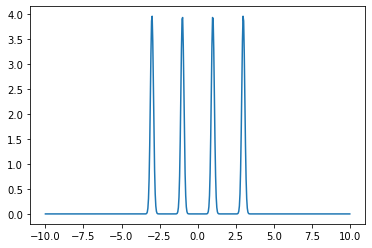

In [283]:
x = np.linspace(-10, 10, 500)
y = 1/(np.sqrt(2*np.pi)*0.1) * np.exp(-(x+1)**2/(2*0.1**2)) \
                            + 1/(np.sqrt(2*np.pi)*0.1) * np.exp(-(x-1)**2/(2*0.1**2)) \
                                + 1/(np.sqrt(2*np.pi)*0.1) * np.exp(-(x-3)**2/(2*0.1**2)) \
                                + 1/(np.sqrt(2*np.pi)*0.1) * np.exp(-(x+3)**2/(2*0.1**2)) 
plt.plot(x,y)

In [811]:
load()

In [668]:
for m in data.keys():
    for b in ['aug-cc-pcVTZp', 'aug-cc-pcVQZp', 'aug-cc-pcV5Zp']:
        t = retrieve(m, 'ccsdT', b)
        if t != {}:
            print("Dipole for:", m, "", b, "MP2:", t['dipoles_mp2'], "CCSD:", t['dipoles_ccsd'], "CCSD(T):", t['dipoles_ccsdt'])

Dipole for: AlF  aug-cc-pcVTZp MP2: [0, 0, -1.4537, 1.4537] CCSD: [0, 0, -1.4669, 1.4669] CCSD(T): [0, 0, -1.4603, 1.4603]
Dipole for: AlF  aug-cc-pcVQZp MP2: [0, 0, -1.4559, 1.4559] CCSD: [0, 0, -1.4688, 1.4688] CCSD(T): [0, 0, -1.4655, 1.4655]
Dipole for: Ar  aug-cc-pcVTZp MP2: [0.0, 0.0, 0.0, 0.0] CCSD: [0.0, 0.0, 0.0, 0.0] CCSD(T): [0.0, 0.0, 0.0, 0.0]
Dipole for: Ar  aug-cc-pcVQZp MP2: [0.0, 0.0, 0.0, 0.0] CCSD: [0.0, 0.0, 0.0, 0.0] CCSD(T): [0.0, 0.0, 0.0, 0.0]
Dipole for: Ar  aug-cc-pcV5Zp MP2: [0.0, 0.0, 0.0, 0.0] CCSD: [0.0, 0.0, 0.0, 0.0] CCSD(T): [0.0, 0.0, 0.0, 0.0]
Dipole for: BeH  aug-cc-pcVTZp MP2: [0.0, 0.0, 0.2824, 0.2824] CCSD: [0.0, 0.0, 0.2331, 0.2331] CCSD(T): [0.0, 0.0, 0.2297, 0.2297]
Dipole for: BeH  aug-cc-pcVQZp MP2: [0.0, 0.0, 0.262, 0.262] CCSD: [0.0, 0.0, 0.234, 0.234] CCSD(T): [0.0, 0.0, 0.2298, 0.2298]
Dipole for: BeH  aug-cc-pcV5Zp MP2: [0, 0, 0.2625, 0.2625] CCSD: [0, 0, 0.2351, 0.2351] CCSD(T): [0, 0, 0.2311, 0.2311]
Dipole for: BeH2  aug-cc-pcVTZp MP2

Dipole for: H-  aug-cc-pcVQZp MP2: [0, 0, 0, 0] CCSD: [0, 0, 0, 0] CCSD(T): [0, 0, 0, 0]
Dipole for: H-  aug-cc-pcV5Zp MP2: [0, 0, 0, 0] CCSD: [0, 0, 0, 0] CCSD(T): [0, 0, 0, 0]
Dipole for: OH-  aug-cc-pcVTZp MP2: [] CCSD: [] CCSD(T): []
Dipole for: OH-  aug-cc-pcVQZp MP2: [] CCSD: [] CCSD(T): []
Dipole for: OH-  aug-cc-pcV5Zp MP2: [] CCSD: [] CCSD(T): []
Dipole for: SH-  aug-cc-pcVTZp MP2: [] CCSD: [] CCSD(T): []
Dipole for: SH-  aug-cc-pcVQZp MP2: [] CCSD: [] CCSD(T): []
Dipole for: SH-  aug-cc-pcV5Zp MP2: [] CCSD: [] CCSD(T): []


In [801]:
save(data)

b"\x1bSaving updates to GitHub...\x1b\nOn branch master\nYour branch is up to date with 'origin/master'.\n\nChanges not staged for commit:\n\tmodified:   ../geometries/cbs_limit/BN_ccsdT_aug-cc-pcV5Z.inp\n\tdeleted:    ../geometries/cbs_limit/BN_ccsdT_aug-cc-pcVDZ.inp\n\tmodified:   ../geometries/cbs_limit/BN_ccsdT_aug-cc-pcVQZ.inp\n\tmodified:   ../geometries/cbs_limit/BN_ccsdT_aug-cc-pcVTZ.inp\n\tmodified:   ../geometries/cbs_limit/CS_ccsdT_aug-cc-pcV5Z.inp\n\tdeleted:    ../geometries/cbs_limit/CS_ccsdT_aug-cc-pcVDZ.inp\n\tmodified:   ../geometries/cbs_limit/CS_ccsdT_aug-cc-pcVQZ.inp\n\tmodified:   ../geometries/cbs_limit/CS_ccsdT_aug-cc-pcVTZ.inp\n\tmodified:   ../geometries/cbs_limit/LiCl_ccsdT_aug-cc-pcV5Z.inp\n\tdeleted:    ../geometries/cbs_limit/LiCl_ccsdT_aug-cc-pcVDZ.inp\n\tmodified:   ../geometries/cbs_limit/LiCl_ccsdT_aug-cc-pcVQZ.inp\n\tmodified:   ../geometries/cbs_limit/LiCl_ccsdT_aug-cc-pcVTZ.inp\n\tdeleted:    ../geometries/cbs_limit/LiCl_ccsdT_dz.inp\n\tmodified:   .

In [848]:
data['SCl2']

[{'name': 'SCl2',
  'method': 'B97-2',
  'basis': 'aug-pc-4p',
  'method_type': 'dft',
  'method_level': 4,
  'quadrupoles': [-38.7861, -36.1978, -35.8504],
  'quadrupoles_off_diag': [0.0, 0.0, -0.0],
  'dipoles': [-0.0, 0.0, 0.3565, 0.3565],
  'quadrupoles_elec': [-28.8365732697, -327.7191573151361, -87.99529923301631],
  'dipoles_elec': [-0.0, 0.0, 0.14214763194999894, 0.14214763194999894],
  'std_dev': [0.7594283806877381, 2.5601529536929473, 1.3266114360582826],
  'spin_polarized': 0},
 {'name': 'SCl2',
  'method': 'HFLYP',
  'basis': 'aug-pc-4p',
  'method_type': 'dft',
  'method_level': 4,
  'quadrupoles': [-39.0144, -36.553, -36.0912],
  'quadrupoles_off_diag': [0.0, 0.0, -0.0],
  'dipoles': [0.0, 0.0, 0.4949, 0.4949],
  'quadrupoles_elec': [-29.006309068800004,
   -327.98324034553605,
   -88.1743284946163],
  'dipoles_elec': [0.0, 0.0, 0.19659838546999897, 0.19659838546999897],
  'std_dev': [0.761660148213099, 2.5611842586800977, 1.3279574953748552],
  'spin_polarized': 0},
 {'

In [948]:
save(data)

b"\x1bSaving updates to GitHub...\x1b\nOn branch master\nYour branch is up to date with 'origin/master'.\n\nChanges not staged for commit:\n\tmodified:   ../geometries/cbs_limit/BN_ccsdT_aug-cc-pcV5Z.inp\n\tdeleted:    ../geometries/cbs_limit/BN_ccsdT_aug-cc-pcVDZ.inp\n\tmodified:   ../geometries/cbs_limit/BN_ccsdT_aug-cc-pcVQZ.inp\n\tmodified:   ../geometries/cbs_limit/BN_ccsdT_aug-cc-pcVTZ.inp\n\tmodified:   ../geometries/cbs_limit/CS_ccsdT_aug-cc-pcV5Z.inp\n\tdeleted:    ../geometries/cbs_limit/CS_ccsdT_aug-cc-pcVDZ.inp\n\tmodified:   ../geometries/cbs_limit/CS_ccsdT_aug-cc-pcVQZ.inp\n\tmodified:   ../geometries/cbs_limit/CS_ccsdT_aug-cc-pcVTZ.inp\n\tmodified:   ../geometries/cbs_limit/LiCl_ccsdT_aug-cc-pcV5Z.inp\n\tdeleted:    ../geometries/cbs_limit/LiCl_ccsdT_aug-cc-pcVDZ.inp\n\tmodified:   ../geometries/cbs_limit/LiCl_ccsdT_aug-cc-pcVQZ.inp\n\tmodified:   ../geometries/cbs_limit/LiCl_ccsdT_aug-cc-pcVTZ.inp\n\tdeleted:    ../geometries/cbs_limit/LiCl_ccsdT_dz.inp\n\tmodified:   .

In [952]:
load()